100%|██████████| 170M/170M [00:12<00:00, 13.3MB/s] 
/Users/austinb.dev.bc/Projects/gap/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


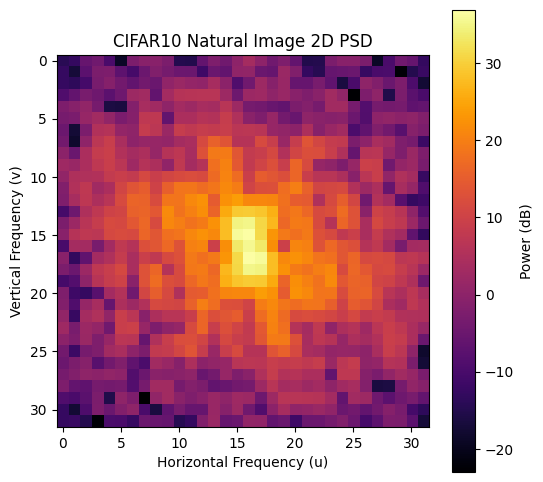

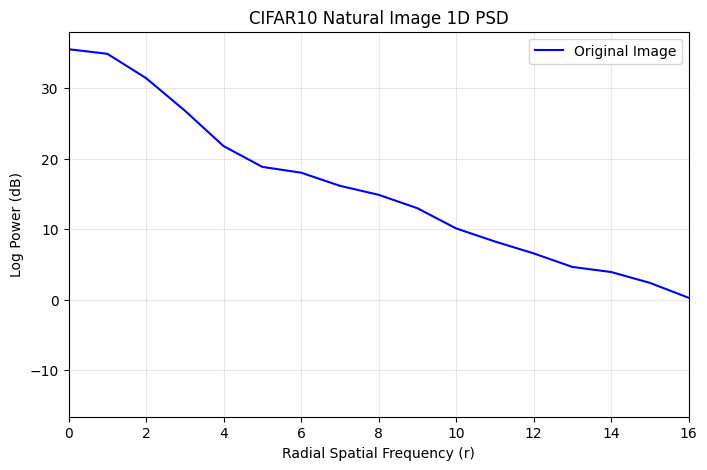

In [1]:
from torchvision import datasets, transforms
from gap.psd import FFT, PSD

# 1. Load a CIFAR10 image as a tensor
transform = transforms.ToTensor()
cifar = datasets.CIFAR10(root='../data', train=True, download=True, transform=transform)
image_tensor, label = cifar[0]  # Shape: (3, 32, 32)

# 2. (Optional but recommended for speed) Create FFT operator once for the dataset
cifar_fft = FFT(spatial_shape=(32, 32))

# 3. Wrap image and compute PSD
image_psd = PSD(image_tensor)
raw_power = image_psd.compute(fft_operator=cifar_fft)

# 4. Plot it!
image_psd.plot(title="CIFAR10 Natural Image 2D PSD")
image_psd.plot_1d(title="CIFAR10 Natural Image 1D PSD")
